In [1]:
using SBMLToolkit, ModelingToolkit, DifferentialEquations, StochasticDiffEq
using Plots
using DataFrames
using CSV
using Random
using Distributions
using SBML
using SymbolicUtils
using StaticArrays
using Catalyst
using AdvancedMH
using MCMCChains
using MCMCChainsStorage
using HDF5
using AbstractMCMC
using KernelDensity
# import StatsPlots

using NPZ # to store converged samples as numpy output
using JLD2
using HDF5
using Distances


using Particles
using ParticlesDE
using StaticDistributions

base_dir = dirname(dirname(pwd()))

include(joinpath(base_dir, "code/utils/utilities.jl"))
include(joinpath(base_dir, "code/epmodels/utils/posEM.jl"))

# SEIR Virus-variant model

In this notebook we introduce the SEIR model with one variant that enters after some time. 

We will create some artificial data for that model as well.

In [2]:
# import the model simulator
model_file = joinpath(base_dir, "code/epmodels/virus_variant_est_infc.jl")
include(model_file)

SEIR_Variant_Model_Ensemble_Simulation (generic function with 1 method)

In [3]:
# import the SBML model
model_name = "covid_ethiopia_seir_variant_model_real_pop_current"
petab_folder = joinpath(base_dir, "petab/virus_variant_model")
sbml_file = string(petab_folder, "/", model_name, ".sbml")

# species ordering is: [E_w, S, R_var, E_var_w, I_w, I_var_w, E_var, R_var_w, R_w, I_var]
init_N = 180000
init_I = 500
init_var = 100
initial_state = [0, init_N-init_I, 0, 0, init_I, 0, 0, 0, 0, 0]

# parameter mapping, first empty to use sbml stored parameters
parammap = []

# create the SDE problem
sdeprob = sbml_to_SDEProblem(sbml_file, parammap, endtime=400.0, initial_state=initial_state);

The parameter vector consists of $[\gamma^{-1}, \kappa^{-1}, \beta, t, scaling, I_0, \text{Infc}_{var}]$, where $[\gamma^{-1}, \kappa^{-1}, \beta, t,]$ are stored in the SDE-problem already.

In [4]:
# get parameter [gamma_inverse, kappa_inverse, beta, t, compartment_volume] from sbml model
sde_par = sdeprob.p

# setup a full parameter vector 
scaling = 2.3
initial_infc = 500.00
init_var = 100.0

test_par = [sde_par[1:4]..., scaling, initial_infc, init_var];

In [5]:
# simulate sde problem with insertion of the variant as a callback

tevent= test_par[4]
jumpsize = test_par[7]

make_event_cb(tevent, jumpsize) = DiscreteCallback((u,t,integrator) -> t == tevent, integrator -> integrator.u[10] += jumpsize)
cb = make_event_cb(tevent, jumpsize)

solve_kwargs = (dt=1e-2, callback=cb, tstops=[tevent], dense=true, force_dtmin=true)
nothing

sde_sol = solve(sdeprob, PositiveEM(); solve_kwargs...);

In [ ]:
plot(sde_sol)

# Inference

## Evaluate Particle number

In [ ]:
true_par = test_par

# define prior
struct SEIR_Prior end

function Random.rand(rng::AbstractRNG, d::SEIR_Prior)
    γ_inv = rand(rng, Normal(15.7, 6.7))
    κ_inv = rand(rng, LogNormal(1.63, 0.5))
    β = rand(rng, Uniform(0.0, 1.0))
    t_event = rand(rng, Uniform(120, 360))
    scaling = rand(rng, Uniform(0.1, 10.0))
    I0 = rand(rng, Uniform(10.0, 1000.0))
    while true
        if β*γ_inv > 0.95
            break
        end
        β = rand(rng, Uniform(0.0, 1.0))
        γ_inv = rand(rng, Normal(15.7, 6.7))
    end
    return [γ_inv, κ_inv, β, t_event, scaling, I0]
end
Random.rand(d::SEIR_Prior) = rand(Random.default_rng(), d)

function Distributions.logpdf(::SEIR_Prior, x)
    if x[3]*x[1] > 0.95
        return logpdf(Normal(15.7, 6.7), x[1]) + logpdf(LogNormal(1.63, 0.5), x[2]) + logpdf(Uniform(0.0, 1.0), x[3]) + logpdf(Uniform(120, 360), x[4]) + logpdf(Uniform(0.0, 10), x[5]) + logpdf(Uniform(10.0, 1000), x[6])
    else
        return -Inf
    end
end


In [ ]:
# load data and observation settings
nobs = 2
data_df = CSV.read(base_dir * "/data/SEIR2V_full_sparse/seir2v_full_sparse_1.csv", DataFrame) # cluster
infc_counts = data_df[!, "infection_count"]
prev_counts = data_df[!, "Seroprev"]
infc_counts = [x == -1 ? missing : x for x in infc_counts]
prev_counts = [x == -1 ? missing : x for x in prev_counts]
real_data = [[infc_counts[i], prev_counts[i]] for i in eachindex(infc_counts)]
real_data = collect(SVector{nobs, Union{Float64, Missing}}, real_data)

# set observation timepoints
tobs = data_df[!, "timepoint"]
# add initial missing
if tobs[1] != 0.0
    real_data = vcat(missing, real_data)
end;

# observation noise
noise_infc = data_df[!, "Std"] 
noise_prev = data_df[!, "Std_1"]

#load likelihood script
include("SEIRSparseNormalDataFilterSetup.jl")

In [ ]:
nruns = 100
nparticles = [10, 50, 100, 200]

theta = [17, 5, 0.08, 150, 3, 500]

SDE_problem = sbml_to_SDEProblem(sbml_file, [], endtime=400.0, initial_state=initial_state);

x = Vector{String}(undef, length(nparticles) * nruns)
y = Vector{Float64}(undef, length(nparticles) * nruns)
variances = Vector{Float64}(undef, length(nparticles))
k = 1
i = 1

for n in nparticles
    logp = log_posterior(n)
    for _ in 1:nruns
        @inbounds x[k] = string(convert(Int, n))
        @inbounds y[k] = logp(theta)
        k += 1
    end
    variances[i] = round(var(y[((i-1)*nruns+1):i*nruns]); digits=3)
    i += 1
end

plt_df = DataFrame(nparticles=x, logp=y);

using Plots.PlotMeasures

x = plt_df.nparticles
y = plt_df.logp
y = reshape(y, (nruns,length(nparticles)))
x_names = reshape(string.(nparticles), (1,length(nparticles)))
labels_list = ["$(nparticles[j])p var: $(variances[j])" for j in 1:length(nparticles)] 
labels = reshape(labels_list, (1,length(nparticles)))

width_px = 1000
plt = Plots.violin(x_names, y, xlabel="Particle number", ylabel="Log-posterior",
        trim=false, labels=labels, legend=:outerright,
        size=(width_px, width_px*2/3), left_margin=20px, bottom_margin=15px, 
        guidefont=font(18), titlefont=font(22), labelfont=font(18), xtickfont=font(18), legendfont=font(18), ytickfont=font(18),
        title="SEIR model: log-posterior estimates for different particle numbers", title_loc=:center)

display(plt)

# savefig(plt, joinpath(base_dir, "output/PF_Experiments/figures/seir_logp_vs_nparticles.pdf"), dpi=300)

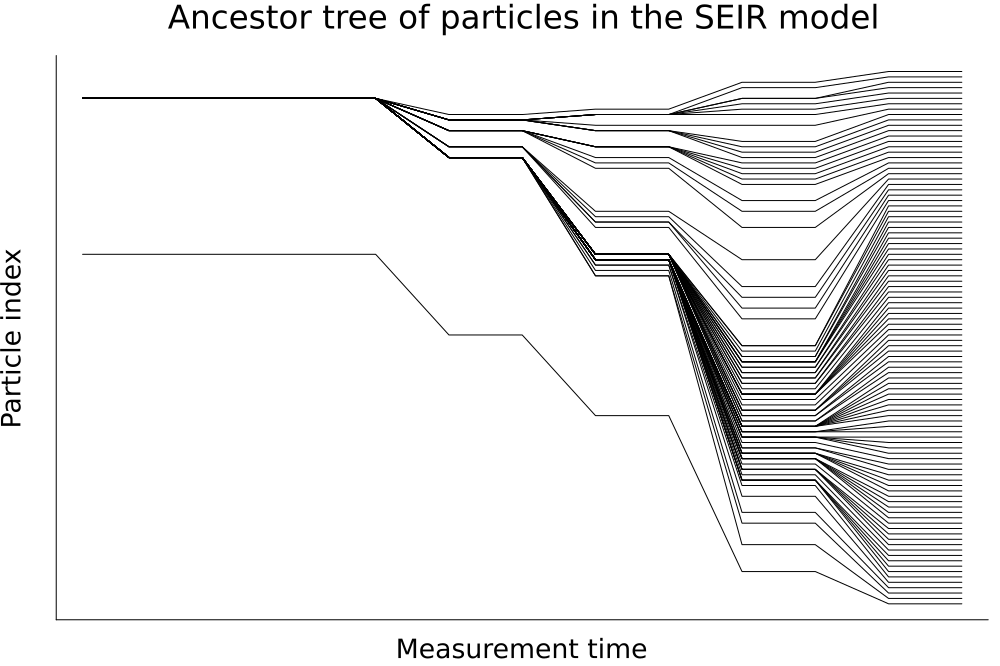

[2, 2, 2, 2, 2, 6, 6, 18, 18, 56, 56, 100, 100][2, 2, 2, 2, 2, 6, 6, 18, 18, 56, 56, 100, 100]

In [ ]:
# define and run one instance of the Bootstrap Filter
ssm = SDEStateSpaceModel(SDE_problem, initial_state, (fobs_normal, (scaling=theta[5],)), nobs, tobs, solve_alg; solve_kwargs...);


bf = BootstrapFilter(ssm, real_data)
pf = SMC(bf, theta, 100, ParticleHistoryLength(; didresample=FullHistory(), ancestors=FullHistory(),
                                                                        logCnorm=StaticFiniteHistory{1}()),
            AdaptiveResampling(SystematicResampling(),0.5),);
offlinefilter!(pf);

print(unique_ancestors_at_previous_times(pf.history_pf.ancestors))

# print the path of particles ancestors as a genealogical tree
# plotlyjs()
print(unique_ancestors_at_previous_times(pf.history_pf.ancestors))
ptree = plot_ancestor_tree(pf.history_pf.ancestors)
plot!(ptree, title="Ancestor tree of particles in the SEIR model", xlabel="Measurement time", ylabel="Particle index")
plot!(ptree, size=(1000,666), left_margin=25px, bottom_margin=15px, top_margin=20px)
plot!(ptree, guidefont=font(18), titlefont=font(22), labelfont=font(18))

display(ptree)
# savefig(ptree, joinpath(base_dir, "output/PF_Experiments/figures/seir_ancestor_tree_example.pdf"))


## Evaluation of results

In [12]:
include(joinpath(base_dir, "code/utils/EvaluateParticleFilter.jl"))

MCMC_diagnostics (generic function with 1 method)

### Synthetic dense data

In [13]:
# filter settings
nparticles=200
nchains = 4
niter = 50000

# set noise model
noise_model ="normal"

# set experiment id
ex_id = 1

#set prior
prior = "normal";

In [ ]:
# set dataset 
datasets = ["1_1", "1_2", "2_1", "2_2"]
dataset = datasets[ex_id]

# parameters are in the ordering [gamma-1, kappa-1, beta, t_event, scaling, I0] in the SDEProblem 
true_pars = [
    [17, 5, 0.08, 150, 3, 500], 
    [11.7, 8.4, 0.23, 222, 1.6, 560], 
    [8, 3, 0.2, 359, 4.2, 915]
    ]
true_par = true_pars[parse(Int, split(dataset, "_")[1])];

# get true parameter dictionary
true_par_dict = Dict(
                :beta => true_par[3],
                :gamma => true_par[1], 
                :kappa => true_par[2], 
                :tevent => true_par[4],
                :scaling => true_par[5],
                :I0 => true_par[6]);

In [ ]:
# load results
chain = h5open(joinpath(base_dir, "output/PF_experiments/SEIR2V_full_dense/seir2v_full_dense_$(dataset)/dense_$(dataset)_$(noise_model)_noise_$(prior)_$(nchains)chs_$(niter)it_$(nparticles)p.h5"), "r") do f
    read(f, Chains)
 end
chain_time = open(joinpath(base_dir, "output/PF_experiments/SEIR2V_full_dense/seir2v_full_dense_$(dataset)/time_dense_$(dataset)_$(noise_model)_noise_$(prior)_$(nchains)chs_$(niter)it_$(nparticles)p.txt"), "r") do f
    read(f, Float64)
end
chain = setinfo(chain, (start_time=0.0, stop_time=chain_time));

if niter > 10000
    burnin = Int(niter-10000)
else
    burnin = Int(niter/10)
end
    
mixed_chain = chain[burnin:end]

# check which chain is converged and remove stuck chains.
stuck_flags = Bool[]
for c in 1:nchains
    chain_slice = mixed_chain[:, :, c]
    n_samples = size(chain_slice, 1)
    last_samples = chain_slice[:, :, 1]
    # Collect quantiles for each parameter
    q_by_param = [quantile(vec(last_samples[:, param, :]), [0.05, 0.5, 0.95]) for param in names(mixed_chain)[2:end]] # first name is likelihood value
    # Check if all quantiles are equal across parameters (i.e. chain not moving)
    all_same = all(q -> all(abs.(q[1] .- q[2:end]) .< 1e-10), q_by_param)
    push!(stuck_flags, all_same)
end
mixed_chain = mixed_chain[:,:, findall(!, stuck_flags)]

if size(mixed_chain, 3) == 0
   error("All chains got stuck! No usable chains remain.")
end
mixed_chain

Chains MCMC chain (10002×7×4 Array{Float64, 3}):

Iterations        = 40000:1:50001
Number of chains  = 4
Samples per chain = 10002
Wall duration     = 24450.8 seconds
Compute duration  = 24450.8 seconds
parameters        = gamma, kappa, beta, tevent, scaling, I0
internals         = lp

Summary Statistics
  parameters       mean       std      mcse    ess_bulk    ess_tail      rhat  ⋯
      Symbol    Float64   Float64   Float64     Float64     Float64   Float64  ⋯

       gamma    15.4238    1.5211    0.0679    493.2763    877.0299    1.0234  ⋯
       kappa     5.4430    1.7533    0.0683    667.7530   1424.9000    1.0100  ⋯
        beta     0.0875    0.0087    0.0004    496.1859    890.3055    1.0224  ⋯
      tevent   154.1855   10.8923    0.3179   1182.2788   2734.0766    1.0071  ⋯
     scaling     3.3149    0.3327    0.0145    518.2295   1019.0249    1.0217  ⋯
          I0   472.1828   52.6872    1.3437   1572.8855   1991.1814    1.0050  ⋯
                                            

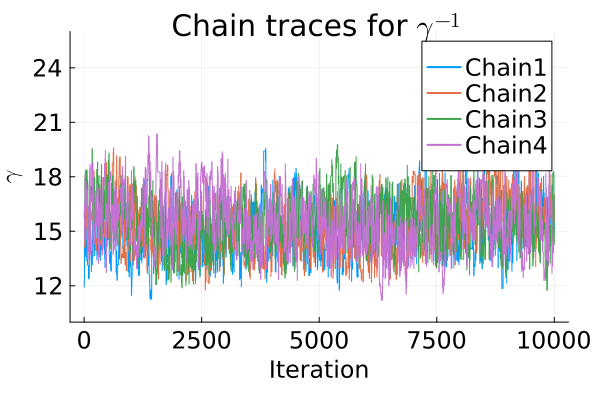

"/home/vincent/PhD/Projects/inference_for_stochastic_systems/Inference-Methods-for-Stochastic-Compartmental-Models/figures/SEIR_gamma_traceplot.svg"

In [ ]:
using LaTeXStrings
using Measures

plt = plot(mixed_chain["gamma"],
    title="", 
    xlabel="Iteration", 
    ylabel=L"$\gamma$",
    ylims=(10,26),
    label=["Chain1" "Chain2" "Chain3" "Chain4"],
    legendfontsize=16,
    guidefont=16,
    tickfont=16,
    titlefont=20,
    top_margin=6Measures.mm, right_margin=6Measures.mm, bottom_margin=6Measures.mm, # small margins are fine
    size=(600,400)
    )

    # Add a custom title, positioned in relative coordinates (x=50%, y=102%)
annotate!(
    plt,
    ((0.5, 1.08),                     # tweak 1.00–1.06 to taste
     Plots.text(L"Chain traces for $\gamma^{-1}$", 20, :center, :top))
)
display(plt)
# savefig(plt, joinpath(base_dir, "output/PF_Experiments/figures/SEIR_gamma_traceplot.svg"))

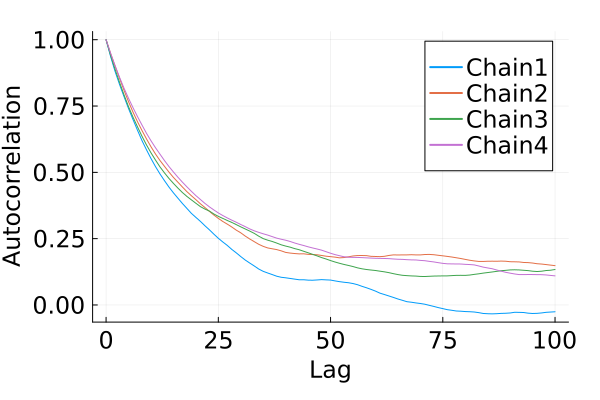

"/home/vincent/PhD/Projects/inference_for_stochastic_systems/Inference-Methods-for-Stochastic-Compartmental-Models/figures/SEIR_gamma_autocorplot.svg"

In [ ]:
plt = MCMCChains.autocorplot(
    mixed_chain[:, [:gamma], :];
    maxlag=100,
    title="",                         # disable default title
    xlabel="Lag",
    ylabel=L"$\gamma$",
    label=["Chain1" "Chain2" "Chain3" "Chain4"],
    legendfontsize=16,
    guidefont=16,
    tickfont=16,
    titlefont=20,
    top_margin=6Measures.mm, right_margin=6Measures.mm, bottom_margin=6Measures.mm, # small margins are fine
    size=(600, 400),
)
plot!(plt, legend=true)
display(plt)
# Add a custom title, positioned in relative coordinates (x=50%, y=102%)
annotate!(
    plt,
    ((0.5, 1.08),                     # tweak 1.00–1.06 to taste
     Plots.text(L"Autocorrelation $\rho_t$ for $\gamma^{-1}$", 20, :center, :top))
)
# savefig(plt,joinpath(base_dir, "output/PF_Experiments/figures/SEIR_gamma_autocorplot.svg"))

In [ ]:
n_samples = 10000
df = DataFrame(mixed_chain)
if nrow(df) >= n_samples
    idx = randperm(nrow(df))[1:n_samples]
    posterior_df = df[idx, :]
else 
    posterior_df = df
end
param_cols = names(posterior_df, Not([:chain, :iteration, :lp]))
parameter_df = posterior_df[:, param_cols]

CSV.write(joinpath(base_dir, "./output/PF_Experiments/SEIR2V_full_dense/seir2v_full_dense_$(dataset)/posterior_samples.csv"), parameter_df)

In [ ]:
# optionally visualize marginal densities and store them
# visualize_chain(mixed_chain, true_par_dict=true_par_dict, save_path=nothing)

# create diagnostics to assess convergence and exploration based on the last 10.000 samples of non-stuck chains extracted above
diagnostics_df = MCMC_diagnostics(mixed_chain, autocorlag=250);

# store diagnostics DataFrame
# CSV.write(joinpath(base_dir, "output/PF_experiments/SEIR2V_full_dense/seir2v_full_dense_$(dataset)/dense_$(dataset)_diagnostics.csv"), diagnostics_df)


"/home/vincent/PhD/Projects/inference_for_stochastic_systems/Inference-Methods-for-Stochastic-Compartmental-Models/output/ParticleFilter/dense_3_2_diagnostics.csv"

### Synthetic sparse data

In [206]:
# filter settings
nparticles=200
nchains = 4
niter = 50000

# set noise model
noise_model ="normal"

# set experiment id
ex_id = 1

#set prior
prior = "normal";

In [207]:
# set dataset 
datasets = ["1_1_1", "1_1_2", "1_1_3", "1_2_1", "1_2_2", "1_2_3"]
dataset = datasets[ex_id]

# parameters are in the ordering [gamma-1, kappa-1, beta, t_event, scaling, I0] in the SDEProblem 
true_pars = [
    [17, 5, 0.08, 150, 3, 500], 
    [11.7, 8.4, 0.23, 222, 1.6, 560]
    ]
true_par = true_pars[parse(Int, split(dataset, "_")[1])];

# get true parameter dictionary
true_par_dict = Dict(
                :beta => true_par[3],
                :gamma => true_par[1], 
                :kappa => true_par[2], 
                :tevent => true_par[4],
                :scaling => true_par[5],
                :I0 => true_par[6]);

In [ ]:
# load results
chain = h5open(joinpath(base_dir, "output/PF_Experiments/SEIR2V_full_sparse/seir2v_full_sparse_$(dataset)/sparse_$(dataset)_$(noise_model)_noise_$(prior)_$(nchains)chs_$(niter)it_$(nparticles)p.h5"), "r") do f
    read(f, Chains)
 end
chain_time = open(joinpath(base_dir, "output/PF_Experiments/SEIR2V_full_sparse/seir2v_full_sparse_$(dataset)/time_sparse_$(dataset)_$(noise_model)_noise_$(prior)_$(nchains)chs_$(niter)it_$(nparticles)p.txt"), "r") do f
    read(f, Float64)
end
chain = setinfo(chain, (start_time=0.0, stop_time=chain_time));

if niter > 10000
    burnin = Int(niter-10000)
else
    burnin = Int(niter/10)
end
    
mixed_chain = chain[burnin:end]

# check which chain is converged and remove stuck chains.
nparams = length(names(mixed_chain))
stuck_flags = Bool[]
for c in 1:nchains
    chain_slice = mixed_chain[:, :, c]
    n_samples = size(chain_slice, 1)
    last_samples = chain_slice[:, :, 1]
    # Collect quantiles for each parameter
    q_by_param = [quantile(vec(last_samples[:, param, :]), [0.05, 0.5, 0.95]) for param in names(mixed_chain)[2:end]] # first name is likelihood value
    # Check if all quantiles are equal across parameters (i.e. chain not moving)
    all_same = all(q -> all(abs.(q[1] .- q[2:end]) .< 1e-10), q_by_param)
    push!(stuck_flags, all_same)
end
mixed_chain = mixed_chain[:,:, findall(!, stuck_flags)]

if size(mixed_chain, 3) == 0
   error("All chains got stuck! No usable chains remain.")
end
mixed_chain

Chains MCMC chain (10002×7×4 Array{Float64, 3}):

Iterations        = 40000:1:50001
Number of chains  = 4
Samples per chain = 10002
Wall duration     = 17197.81 seconds
Compute duration  = 17197.81 seconds
parameters        = gamma, kappa, beta, tevent, scaling, I0
internals         = lp

Summary Statistics
  parameters       mean       std      mcse    ess_bulk    ess_tail      rhat  ⋯
      Symbol    Float64   Float64   Float64     Float64     Float64   Float64  ⋯

       gamma    14.7666    1.7852    0.1008    308.2482    513.0412    1.0638  ⋯
       kappa     5.8490    2.0903    0.0902    543.7580   1166.1374    1.0338  ⋯
        beta     0.0945    0.0113    0.0006    306.4697    518.2630    1.0646  ⋯
      tevent   168.8672   17.7027    0.4496   1551.8163   2626.2822    1.0023  ⋯
     scaling     3.3620    0.4434    0.0232    377.2432    713.1049    1.0520  ⋯
          I0   337.5330   90.9943    2.2462   1659.1328   2482.8516    1.0050  ⋯
                                          

In [ ]:
n_samples = 10000
df = DataFrame(mixed_chain)
if nrow(df) >= n_samples
    idx = randperm(nrow(df))[1:n_samples]
    posterior_df = df[idx, :]
else 
    posterior_df = df
end
param_cols = names(posterior_df, Not([:chain, :iteration, :lp]))
parameter_df = posterior_df[:, param_cols]

CSV.write(joinpath(base_dir, "./output/PF_Experiments/SEIR2V_full_sparse/seir2v_full_sparse_$(dataset)/posterior_samples.csv"), parameter_df)

In [ ]:
# optionally visualize marginal densities and store them
# visualize_chain(mixed_chain, true_par_dict=true_par_dict, save_path=nothing)

# create diagnostics to assess convergence and exploration based on the last 10.000 samples of non-stuck chains extracted above
diagnostics_df = MCMC_diagnostics(mixed_chain, autocorlag=250);

# store diagnostics DataFrame
# CSV.write(joinpath(base_dir, "output/PF_Experiments/SEIR2V_full_sparse/seir2v_full_sparse_$(dataset)/sparse_$(dataset)_diagnostics.csv"), diagnostics_df)

Row,parameter,rhat,gelman,ess_basic
,Symbol,Float64,Float64,Float64
1,gamma,1.06382,1.07816,313.893
2,kappa,1.03384,1.04837,536.541
3,beta,1.06462,1.09193,302.38
4,tevent,1.00227,1.0015,1550.23
5,scaling,1.05202,1.08448,364.365
6,I0,1.005,1.00202,1641.09


### Reparametrized model

In [175]:
# filter settings
nparticles=200
nchains = 4
niter = 50000

# set noise model
noise_model ="normal"

# set experiment id
ex_id = 1

#set prior
prior = "normal";

In [ ]:
# set dataset 
datasets = ["1_1", "1_2"]
dataset = datasets[ex_id]

# parameters are in the ordering [e0, r0, s0, t, I0] in the SDEProblem 
true_pars = [
    [1.36, 22.0, 51.0, 150.0, 500.0], 
    [2.69, 20.1, 18.72, 222, 560], 
    [1.6, 11.0, 33.6, 359, 915]]
true_par = true_pars[parse(Int, split(dataset, "_")[1])]

function original_parameters(p;kappa=5)
    κ_inv = kappa
    γ_inv = p[2]-κ_inv
    β = p[1]/γ_inv
    scaling = p[3]/γ_inv
    t_event = p[4]
    I0 = p[5]
    return [γ_inv, κ_inv, β, t_event, scaling, I0]
end
true_or = original_parameters(true_par)

# get true parameter dictionary
true_par_dict = Dict(
                :r0 => true_par[1],
                :e0 => true_par[2], 
                :s0 => true_par[3], 
                :tevent => true_par[4],
                :I0 => true_par[5]);

In [ ]:
# load results
chain = h5open(joinpath(base_dir, "output/PF_Experiments/SEIR2V_reparam_dense/seir2v_reparam_dense_$(dataset)/reparam_dense_$(dataset)_$(noise_model)_noise_$(prior)_$(nchains)chs_$(niter)it_$(nparticles)p.h5"), "r") do f
    read(f, Chains)
 end
chain_time = open(joinpath(base_dir, "output/PF_Experiments/SEIR2V_reparam_dense/seir2v_reparam_dense_$(dataset)/time_reparam_dense_$(dataset)_$(noise_model)_noise_$(prior)_$(nchains)chs_$(niter)it_$(nparticles)p.txt"), "r") do f
    read(f, Float64)
end
chain = setinfo(chain, (start_time=0.0, stop_time=chain_time));

if niter > 10000
    burnin = Int(niter-10000)
else
    burnin = Int(niter/10)
end
    
mixed_chain = chain[burnin:end]

# check which chain is converged and remove stuck chains.
nparams = length(names(mixed_chain))
stuck_flags = Bool[]
for c in 1:nchains
    chain_slice = mixed_chain[:, :, c]
    n_samples = size(chain_slice, 1)
    last_samples = chain_slice[:, :, 1]
    # Collect quantiles for each parameter
    q_by_param = [quantile(vec(last_samples[:, param, :]), [0.05, 0.5, 0.95]) for param in names(mixed_chain)[2:end]] # first name is likelihood value
    # Check if all quantiles are equal across parameters (i.e. chain not moving)
    all_same = all(q -> all(abs.(q[1] .- q[2:end]) .< 1e-10), q_by_param)
    push!(stuck_flags, all_same)
end
mixed_chain = mixed_chain[:,:, findall(!, stuck_flags)]

if size(mixed_chain, 3) == 0
   error("All chains got stuck! No usable chains remain.")
end
mixed_chain

Chains MCMC chain (10002×6×4 Array{Float64, 3}):

Iterations        = 40000:1:50001
Number of chains  = 4
Samples per chain = 10002
Wall duration     = 226500.78 seconds
Compute duration  = 226500.78 seconds
parameters        = r0, e0, s0, tevent, I0
internals         = lp

Summary Statistics
  parameters       mean       std      mcse    ess_bulk    ess_tail      rhat  ⋯
      Symbol    Float64   Float64   Float64     Float64     Float64   Float64  ⋯

          r0     1.3386    0.0189    0.0004   2408.0988   3261.3986    1.0020  ⋯
          e0    20.9556    1.1277    0.0228   2439.4790   3579.1712    1.0012  ⋯
          s0    50.7406    1.3896    0.0285   2370.8058   3786.8998    1.0049  ⋯
      tevent   153.4326   11.4224    0.2394   2267.8880   2942.9327    1.0031  ⋯
          I0   476.5852   54.3707    1.1140   2384.6363   3652.7415    1.0024  ⋯
                                                                1 column omitted

Quantiles
  parameters       2.5%      25.0%      50.0% 

In [ ]:
n_samples = 10000
df = DataFrame(mixed_chain)
if nrow(df) >= n_samples
    idx = randperm(nrow(df))[1:n_samples]
    posterior_df = df[idx, :]
else 
    posterior_df = df
end
param_cols = names(posterior_df, Not([:chain, :iteration, :lp]))
parameter_df = posterior_df[:, param_cols]

CSV.write(joinpath(base_dir, "./output/PF_Experiments/SEIR2V_reparam_dense/seir2v_reparam_dense_$(dataset)/posterior_samples.csv"), parameter_df)

In [ ]:
# optionally visualize marginal densities and store them
# visualize_chain(mixed_chain, true_par_dict=true_par_dict, save_path=nothing)

# create diagnostics to assess convergence and exploration based on the last 10.000 samples of non-stuck chains extracted above
diagnostics_df = MCMC_diagnostics(mixed_chain, autocorlag=250);

# store diagnostics DataFrame
# CSV.write(joinpath(base_dir, "output/PF_Experiments/SEIR2V_reparam_dense/seir2v_reparam_dense_$(dataset)/reapram_dense_$(dataset)_diagnostics.csv"), diagnostics_df)

Row,parameter,rhat,gelman,ess_basic
,Symbol,Float64,Float64,Float64
1,r0,1.002,1.00064,2409.78
2,e0,1.00124,1.00048,2453.8
3,s0,1.00485,1.00384,2370.52
4,tevent,1.00307,1.00246,2276.18
5,I0,1.00244,1.00028,2382.22


### Real data

In [ ]:
# load results
chain = h5open(joinpath(base_dir, "output/PF_Experiments/SEIR2V_full_real_ethiopia/real_$(noise_model)_$(nchains)chs_$(niter)it_$(nparticles)p.h5"), "r") do f
    read(f, Chains)
 end
chain_time = open(joinpath(base_dir, "output/PF_Experiments/SEIR2V_full_real_ethiopia/time_real_$(noise_model)_$(nchains)chs_$(niter)it_$(nparticles)p.txt"), "r") do f
    read(f, Float64)
end
chain = setinfo(chain, (start_time=0.0, stop_time=chain_time));

if niter > 10000
    burnin = Int(niter-10000)
else
    burnin = Int(niter/10)
end
    
mixed_chain = chain[burnin:end]

# check which chain is converged and remove stuck chains.
nparams = length(names(mixed_chain))
stuck_flags = Bool[]
for c in 1:nchains
    chain_slice = mixed_chain[:, :, c]
    n_samples = size(chain_slice, 1)
    last_samples = chain_slice[:, :, 1]
    # Collect quantiles for each parameter
    q_by_param = [quantile(vec(last_samples[:, param, :]), [0.05, 0.5, 0.95]) for param in names(mixed_chain)[2:end]] # first name is likelihood value
    # Check if all quantiles are equal across parameters (i.e. chain not moving)
    all_same = all(q -> all(abs.(q[1] .- q[2:end]) .< 1e-10), q_by_param)
    push!(stuck_flags, all_same)
end
mixed_chain = mixed_chain[:,:, findall(!, stuck_flags)]

if size(mixed_chain, 3) == 0
   error("All chains got stuck! No usable chains remain.")
end
mixed_chain

Chains MCMC chain (10002×7×4 Array{Float64, 3}):

Iterations        = 40000:1:50001
Number of chains  = 4
Samples per chain = 10002
Wall duration     = 171979.71 seconds
Compute duration  = 171979.71 seconds
parameters        = gamma, kappa, beta, tevent, scaling, I0
internals         = lp

Summary Statistics
  parameters       mean        std      mcse    ess_bulk    ess_tail      rhat ⋯
      Symbol    Float64    Float64   Float64     Float64     Float64   Float64 ⋯

       gamma    14.3730     1.9697    0.0957    409.2066    615.4368    1.0338 ⋯
       kappa     4.6891     1.4911    0.0412   1322.9459   2755.6393    1.0039 ⋯
        beta     0.0923     0.0117    0.0006    419.4849    579.0516    1.0325 ⋯
      tevent   185.2221    32.0210    1.0339    949.5415   2348.1493    1.0069 ⋯
     scaling     3.5366     1.0713    0.0379    905.7123   1234.3510    1.0106 ⋯
          I0   610.5826   214.4987    7.9144    745.9636   2028.6759    1.0058 ⋯
                                        

In [ ]:
n_samples = 10000
df = DataFrame(mixed_chain)
if nrow(df) >= n_samples
    idx = randperm(nrow(df))[1:n_samples]
    posterior_df = df[idx, :]
else 
    posterior_df = df
end
param_cols = names(posterior_df, Not([:chain, :iteration, :lp]))
parameter_df = posterior_df[:, param_cols]

CSV.write(joinpath(base_dir, "./output/PF_Experiments/SEIR2V_full_real_ethiopia/posterior_samples.csv"), parameter_df)

In [ ]:
# optionally visualize marginal densities and store them
# visualize_chain(mixed_chain, save_path=nothing)

# create diagnostics to assess convergence and exploration based on the last 10.000 samples of non-stuck chains extracted above
diagnostics_df = MCMC_diagnostics(mixed_chain, autocorlag=250);

# store diagnostics DataFrame
# CSV.write(joinpath(base_dir, "output/PF_Experiments/SEIR2V_full_real_ethiopia/real_data_diagnostics.csv"), diagnostics_df)

Row,parameter,rhat,gelman,ess_basic
,Symbol,Float64,Float64,Float64
1,gamma,1.03379,1.04169,423.756
2,kappa,1.00393,1.00365,1311.96
3,beta,1.03253,1.03986,407.34
4,tevent,1.00686,1.00793,959.159
5,scaling,1.01063,1.02109,798.551
6,I0,1.00583,1.00509,734.542
